In [ ]:
import subprocess

archive_path = '/kaggle/input/datasets/juliaosnovskaia/airplanes/HRPlanes.7z.001'
extract_path = '/kaggle/working/'

subprocess.run(
    ['7z', 'x', archive_path, f'-o{extract_path}', '-y'],
    check=True
)
print("Распаковка завершена!")


7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,4 CPUs Intel(R) Xeon(R) CPU @ 2.00GHz (50653),ASM,AES-NI)

Scanning the drive for archives:
1 file, 1073741824 bytes (1024 MiB)

Extracting archive: /kaggle/input/datasets/juliaosnovskaia/airplanes/HRPlanes.7z.001
--
Path = /kaggle/input/datasets/juliaosnovskaia/airplanes/HRPlanes.7z.001
Type = Split
Physical Size = 1073741824
Volumes = 10
Total Physical Size = 9984490096
----
Path = HRPlanes.7z
Size = 9984490096
--
Path = HRPlanes.7z
Type = 7z
Physical Size = 9984490096
Headers Size = 55175
Method = LZMA2:28
Solid = +
Blocks = 1

Everything is Ok

Folders: 1
Files: 6189
Size:       11400963921
Compressed: 9984490096
Распаковка завершена!


In [ ]:
import shutil
from pathlib import Path

SRC_DIR = Path("/kaggle/working/img")          
SPLITS_DIR = Path("/kaggle/working")          
OUT_DIR = Path("/kaggle/working/hrplanes_yolo")

for split in ['train', 'val', 'test']:
    (OUT_DIR / split / 'images').mkdir(parents=True, exist_ok=True)
    (OUT_DIR / split / 'labels').mkdir(parents=True, exist_ok=True)

split_files = {
    'train': SPLITS_DIR / 'train.txt',
    'val': SPLITS_DIR / 'validation.txt',
    'test': SPLITS_DIR / 'test.txt'
}

stats = {'moved': 0, 'missing_img': 0, 'missing_txt': 0}

for split_name, txt_path in split_files.items():
    if not txt_path.exists():
        print(f"{txt_path.name} не найден. Пропускаем.")
        continue
        
    with open(txt_path, 'r', encoding='utf-8') as f:
        lines = [l.strip() for l in f if l.strip()]
        
    print(f"Обработка {split_name}: {len(lines)} файлов")
    
    for line in lines:
        img_name = Path(line).name
        src_img = SRC_DIR / img_name
        
        if not src_img.exists():
            stats['missing_img'] += 1
            continue
            
        dest_img = OUT_DIR / split_name / 'images' / img_name
        shutil.move(str(src_img), str(dest_img))
        
        txt_name = img_name.rsplit('.', 1)[0] + '.txt'
        src_txt = SRC_DIR / txt_name
        if src_txt.exists():
            dest_txt = OUT_DIR / split_name / 'labels' / txt_name
            shutil.move(str(src_txt), str(dest_txt))
            stats['moved'] += 1
        else:
            stats['missing_txt'] += 1

print("\nРаспределение завершено.")
print(f"Успешно перемещено пар: {stats['moved']}")
print(f"Не найдено изображений: {stats['missing_img']}")
print(f"Не найдено аннотаций: {stats['missing_txt']}")

Обработка train: 2170 файлов
Обработка val: 620 файлов
Обработка test: 311 файлов

Распределение завершено.
Успешно перемещено пар: 3082
Не найдено изображений: 11
Не найдено аннотаций: 8


In [ ]:
import os
import shutil
from pathlib import Path

WORK_DIR = Path("/kaggle/working")
OUT_DIR = WORK_DIR / "hrplanes_yolo"
TEMP_DIR = WORK_DIR / "temp_recovery"
SPLITS_DIR = WORK_DIR  

TEMP_DIR.mkdir(exist_ok=True)
scan_dirs = [WORK_DIR / "img", OUT_DIR]

for src in scan_dirs:
    if not src.exists():
        continue
    for f in src.rglob("*"):
        if f.is_file() and f.suffix.lower() in {'.jpg', '.jpeg', '.png', '.txt'}:
            dest = TEMP_DIR / f.name
            if not dest.exists():
                shutil.move(str(f), str(dest))

print(f" Временная папка собрана: {len(list(TEMP_DIR.iterdir()))} файлов")

if OUT_DIR.exists():
    shutil.rmtree(OUT_DIR)
for split in ['train', 'validation', 'test']:
    (OUT_DIR / split / 'images').mkdir(parents=True, exist_ok=True)
    (OUT_DIR / split / 'labels').mkdir(parents=True, exist_ok=True)

split_files = {
    'train': SPLITS_DIR / 'train.txt',
    'validation': SPLITS_DIR / 'validation.txt',
    'test': SPLITS_DIR / 'test.txt'
}

stats = {'moved_img': 0, 'moved_txt': 0, 'missing': 0}

for split_name, txt_path in split_files.items():
    if not txt_path.exists():
        print(f" {txt_path.name} не найден")
        continue
        
    with open(txt_path, 'r', encoding='utf-8') as f:
        filenames = [Path(line.strip()).name for line in f if line.strip()]
        
    for fname in filenames:
        img_src = TEMP_DIR / fname
        if img_src.exists():
            shutil.move(str(img_src), str(OUT_DIR / split_name / 'images' / fname))
            stats['moved_img'] += 1
        else:
            stats['missing'] += 1
            
        txt_name = fname.rsplit('.', 1)[0] + '.txt'
        txt_src = TEMP_DIR / txt_name
        if txt_src.exists():
            shutil.move(str(txt_src), str(OUT_DIR / split_name / 'labels' / txt_name))
            stats['moved_txt'] += 1

shutil.rmtree(TEMP_DIR, ignore_errors=True)

print("\n Восстановление завершено.")
print(f"  Перемещено изображений: {stats['moved_img']}")
print(f"  Перемещено аннотаций: {stats['moved_txt']}")
print(f"  Не найдено в источнике: {stats['missing']}")

In [ ]:
from pathlib import Path

BASE = Path("/kaggle/working/hrplanes_yolo")


def sync_split(split_name):
    img_dir = BASE / split_name / "images"
    lbl_dir = BASE / split_name / "labels"

    imgs = {
        f.stem
        for f in img_dir.iterdir()
        if f.suffix.lower() in {".jpg", ".jpeg", ".png"}
    }
    lbls = {f.stem for f in lbl_dir.iterdir() if f.suffix == ".txt"}

    for stem in imgs - lbls:
        for ext in [".jpg", ".jpeg", ".png"]:
            f = img_dir / f"{stem}{ext}"
            if f.exists():
                f.unlink()
                print(f" Удалено изображение без аннотации: {split_name}/{stem}")

    for stem in lbls - imgs:
        f = lbl_dir / f"{stem}.txt"
        if f.exists():
            f.unlink()
            print(f"Удалена аннотация без изображения: {split_name}/{stem}")


for split in ["train", "validation", "test"]:
    sync_split(split)

print("\nИтоговая проверка:")
for split in ["train", "validation", "test"]:
    img_dir = BASE / split / "images"
    lbl_dir = BASE / split / "labels"
    imgs = len(list(img_dir.iterdir()))
    lbls = len(list(lbl_dir.iterdir()))
    status = " OK" if imgs == lbls else " MISMATCH"
    print(f"{split:>8}: images={imgs:>4}, labels={lbls:>4} [{status}]")

In [27]:
!echo "Train img: $(ls /kaggle/working/hrplanes_yolo/train/images | wc -l) | lbl: $(ls /kaggle/working/hrplanes_yolo/train/labels | wc -l)"
!echo "Val   img: $(ls /kaggle/working/hrplanes_yolo/validation/images | wc -l) | lbl: $(ls /kaggle/working/hrplanes_yolo/validation/labels | wc -l)"
!echo "Test  img: $(ls /kaggle/working/hrplanes_yolo/test/images | wc -l) | lbl: $(ls /kaggle/working/hrplanes_yolo/test/labels | wc -l)"

Train img: 2156 | lbl: 2156
Val   img: 616 | lbl: 616
Test  img: 310 | lbl: 310


In [23]:
from pathlib import Path

data_yaml_content = """path: /kaggle/working/hrplanes_yolo
train: train/images
val: validation/images
test: test/images

nc: 1
names: ['airplane']
"""

DATA_YAML = Path("/kaggle/working/hrplanes_yolo/data.yaml")
DATA_YAML.write_text(data_yaml_content.strip(), encoding="utf-8")

print("data.yaml создан корректно:")
print(DATA_YAML.read_text())

data.yaml создан корректно:
path: /kaggle/working/hrplanes_yolo
train: train/images
val: validation/images
test: test/images

nc: 1
names: ['airplane']


In [ ]:
import os
import torch
from pathlib import Path
from ultralytics import YOLO

BASE_DIR = Path("/kaggle/working/hrplanes_yolo")
DATA_YAML = BASE_DIR / "data.yaml"


model = YOLO("yolov8s.pt")  # Transfer learning с COCO
print("\nЗапуск обучения...")
results = model.train(
    data=str(DATA_YAML),
    imgsz=640,
    epochs=100,
    
    batch=32,           # 32 всего = 16 на каждую T4
    device=[0, 1],      # Явно указываем обе GPU для DDP-тренировки
    
    optimizer="AdamW",
    lr0=0.001,
    lrf=0.01,
    weight_decay=0.0005,
    
    augment=True,
    mosaic=1.0,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    flipud=0.5,
    fliplr=0.5,
    
    workers=4,          # 2 на каждую GPU
    cache=False,        # Отключено: изображения 4800×2703 не влезут в RAM
    amp=True,           # Mixed precision: экономит ~40% VRAM на T4
    
    patience=20,        # Early stopping если mAP не растёт 20 эпох
    close_mosaic=10,    # Отключаем mosaic на последних эпохах для стабильности
    
    project="/kaggle/working/yolo_results",
    name="hrplanes_v8s_t4x2",
    save=True,
    save_period=10,     # Сохранять веса каждые 10 эпох (страховка от прерывания Kaggle)
    exist_ok=True,
    
    val=True,           # Валидация после каждой эпохи
    plots=True,         # Сохранять графики PR-кривой, confusion matrix и др.
)

print(f"Лучшие метрики:")
print(f"   mAP50-95: {results.results_dict.get('metrics/mAP50-95(B)', 'N/A'):.4f}")
print(f"   mAP50:    {results.results_dict.get('metrics/mAP50(B)', 'N/A'):.4f}")


Запуск обучения...
Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/hrplanes_yolo/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=

AttributeError: 'NoneType' object has no attribute 'results_dict'

In [ ]:

best_model = YOLO(f"/kaggle/working/yolo_results/hrplanes_v8s_t4x2/weights/best.pt")

metrics = best_model.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=640,
    batch=32,
    device=[0, 1],
    plots=True,
    save_json=True  
)

print(f"\n Тестовые метрики:")
print(f"   mAP50-95: {metrics.results_dict['metrics/mAP50-95(B)']:.4f}")
print(f"   Precision: {metrics.results_dict['metrics/precision(B)']:.4f}")
print(f"   Recall:    {metrics.results_dict['metrics/recall(B)']:.4f}")

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 145.8±31.8 MB/s, size: 4492.4 KB)
val: Scanning /kaggle/working/hrplanes_yolo/test/labels... 310 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 310/310 543.2it/s 0.6s0.1s
val: New cache created: /kaggle/working/hrplanes_yolo/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.1s/it 21.2s.0ss
                   all        310       1924      0.991      0.982      0.994      0.857
Speed: 0.5ms preprocess, 6.3ms inference, 0.0ms loss, 0.9ms postprocess per image
Saving /kaggle/working/runs/detect/val/predictions.json...
Results saved to /kaggle/working/runs/detect/val

 Тестовые метрики:
   mAP50-95: 0.8566
   

In [ ]:

best_model = YOLO(f"/kaggle/working/yolo_results/hrplanes_v8s_t4x2/weights/best.pt")

metrics = best_model.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=640,
    batch=32,
    device=[0, 1],
    plots=True,
    save_json=True
)

print("Все доступные метрики в results_dict:")
for key in sorted(metrics.results_dict.keys()):
    print(f"   {key}: {metrics.results_dict[key]}")

print("\n" + "="*60)
print("ОСНОВНЫЕ МЕТРИКИ (тестовый сплит)")
print("="*60)

# Основные метрики детекции
main_metrics = {
    "mAP50-95": "metrics/mAP50-95(B)",
    "mAP50": "metrics/mAP50(B)",
    "Precision": "metrics/precision(B)",
    "Recall": "metrics/recall(B)",
    "F1-score": "metrics/F1(B)",
}

for label, key in main_metrics.items():
    if key in metrics.results_dict:
        value = metrics.results_dict[key]
        print(f"{label:>12}: {value:.4f}")
    else:
        print(f"{label:>12}: N/A")

print("\n" + "="*60)
print("МЕТРИКИ ПО КЛАССАМ")
print("="*60)

# Класс-специфичные метрики имеют суффикс (B) для box или (M) для mask
class_metrics = [
    "metrics/precision(B)",
    "metrics/recall(B)", 
    "metrics/mAP50(B)",
    "metrics/mAP50-95(B)",
    "metrics/F1(B)",
]

for key in class_metrics:
    if key in metrics.results_dict:
        # Для одного класса значение — просто число
        value = metrics.results_dict[key]
        metric_name = key.split("/")[-1].replace("(B)", "").replace("metrics_", "")
        print(f"{metric_name:>12}: {value:.4f}")

print("\n" + "="*60)
print("ТЕХНИЧЕСКИЕ МЕТРИКИ")
print("="*60)

tech_metrics = {
    "Loss/box": "val/box_loss",
    "Loss/cls": "val/cls_loss", 
    "Loss/dfl": "val/dfl_loss",
    "Samples": "metrics/samples",  # количество протестированных изображений
}

for label, key in tech_metrics.items():
    if key in metrics.results_dict:
        value = metrics.results_dict[key]
        if isinstance(value, float):
            print(f"{label:>12}: {value:.4f}")
        else:
            print(f"{label:>12}: {value}")


Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3884.7±156.6 MB/s, size: 3712.5 KB)
val: Scanning /kaggle/working/hrplanes_yolo/test/labels.cache... 310 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 310/310 92.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 1.8s/it 18.1s.0s
                   all        310       1924      0.991      0.982      0.994      0.857
Speed: 0.5ms preprocess, 6.6ms inference, 0.0ms loss, 1.1ms postprocess per image
Saving /kaggle/working/runs/detect/val-7/predictions.json...
Results saved to /kaggle/working/runs/detect/val-7
Все доступные метрики в results_dict:
   fitness: 0.8566073405852744
   metrics/mAP50(B): 0.9938724079493035

Загрузка модели...
Выбрано 6 изображений для визуализации
[1/6] Обработка GBG_930.jpg...


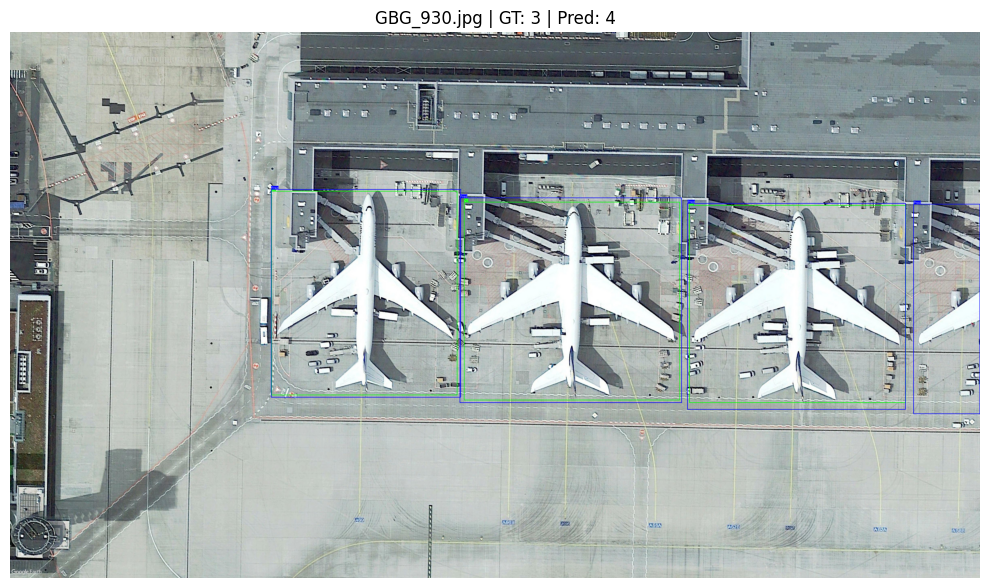

[2/6] Обработка GBG_270.jpg...


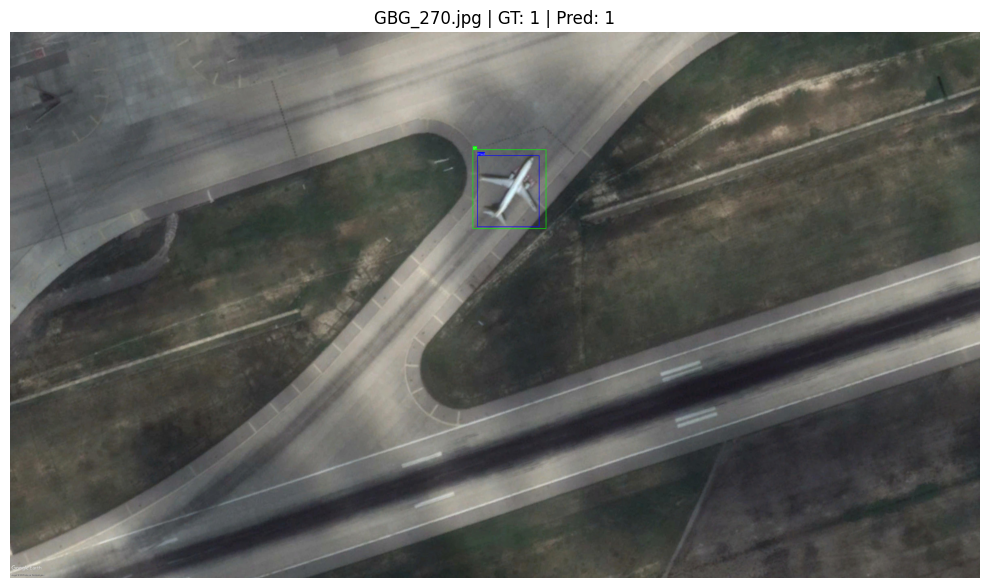

[3/6] Обработка IND_0153.jpg...


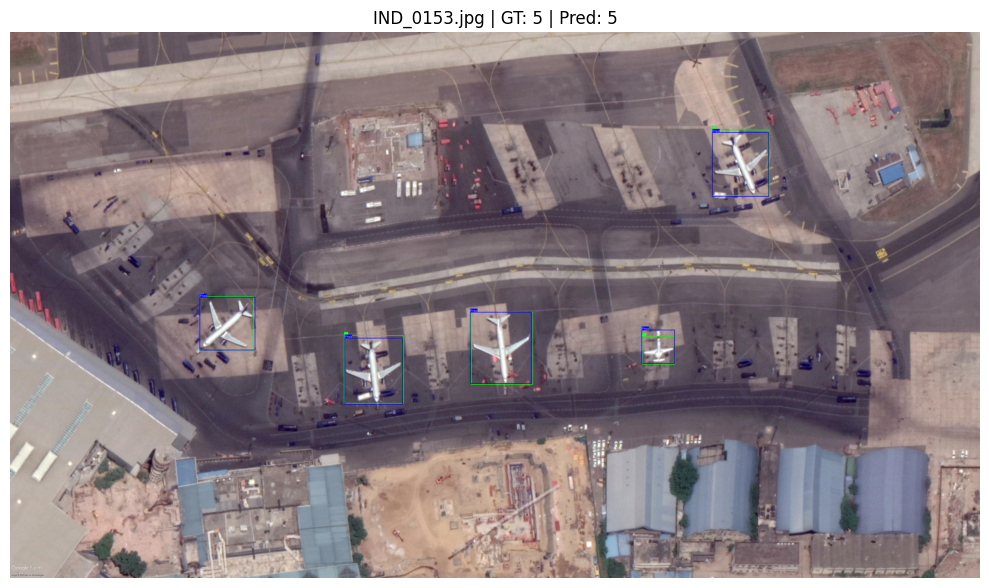

[4/6] Обработка SZX_0009.jpg...


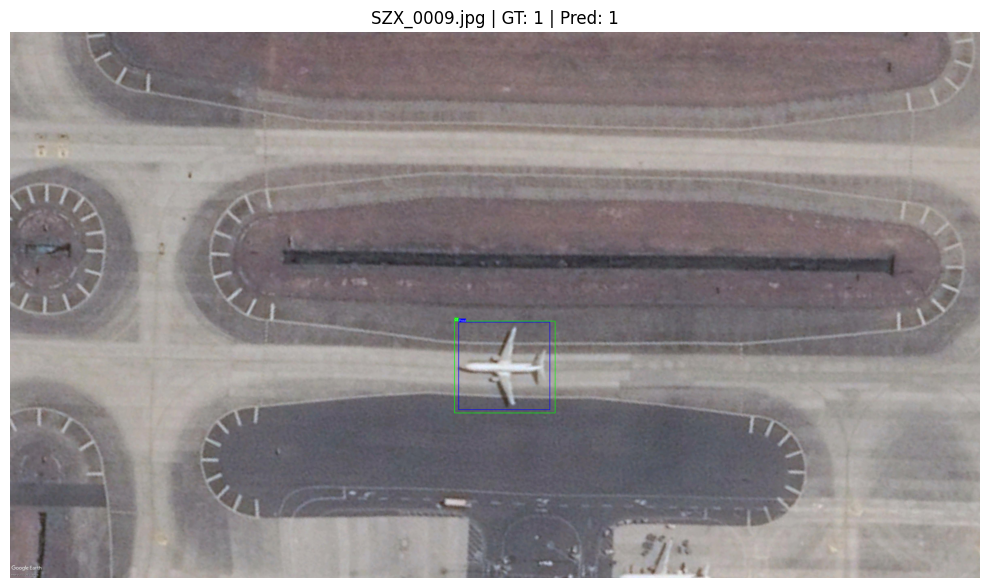

[5/6] Обработка SIN_023.jpg...


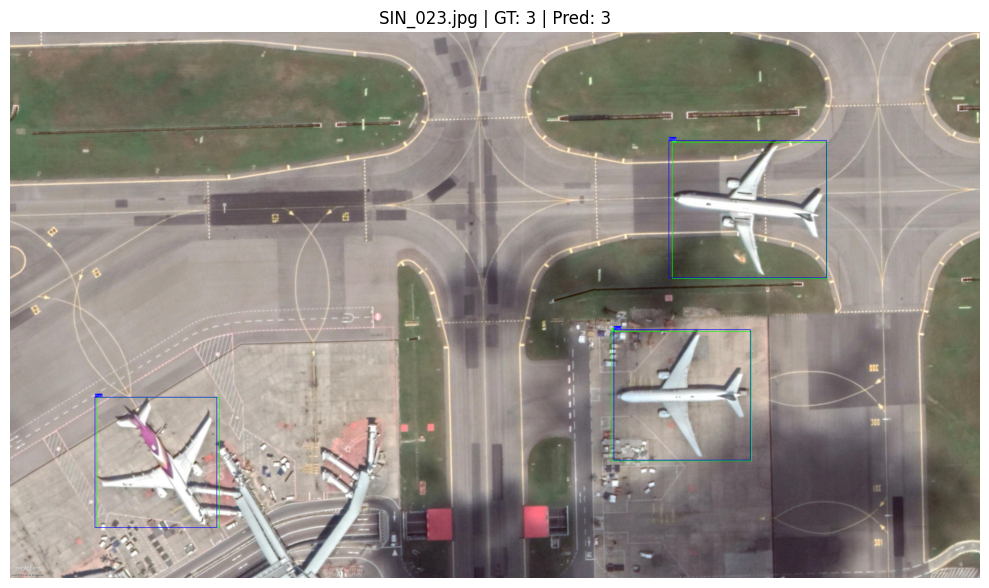

[6/6] Обработка SIN_033.jpg...


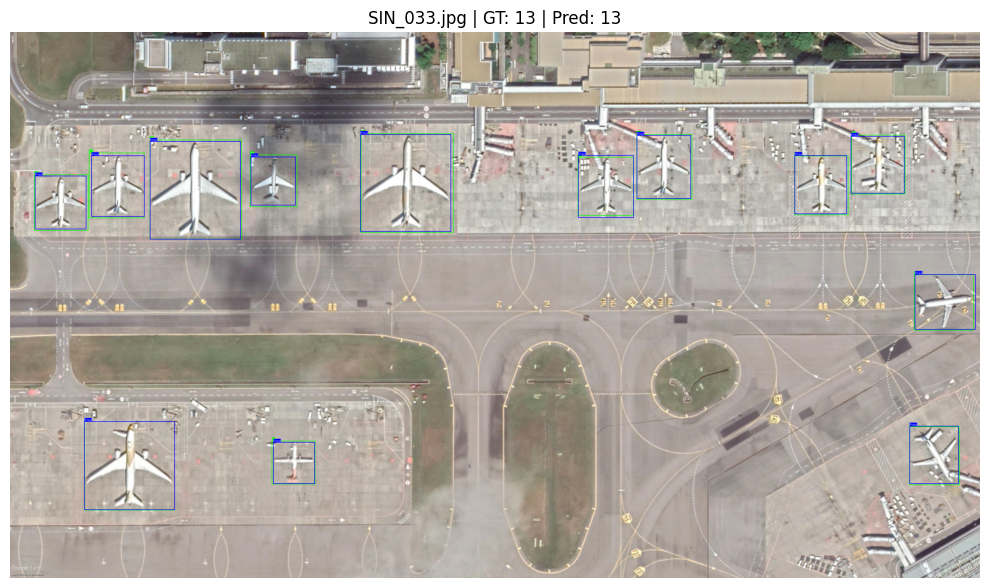

In [ ]:
import cv2
import random
import numpy as np
from pathlib import Path
from ultralytics import YOLO
import matplotlib.pyplot as plt

TEST_IMG_DIR = Path("/kaggle/working/hrplanes_yolo/test/images")
TEST_LBL_DIR = Path("/kaggle/working/hrplanes_yolo/test/labels")
MODEL_PATH = "/kaggle/working/yolo_results/hrplanes_v8s_t4x2/weights/best.pt"
OUTPUT_DIR = Path("/kaggle/working/visualization_samples")
OUTPUT_DIR.mkdir(exist_ok=True)

N_SAMPLES = 6
CONF_THRESH = 0.25

COLOR_GT = (0, 255, 0)      # Зеленый для Ground Truth
COLOR_PRED = (255, 0, 0)    # Синий для предсказаний модели

def yolo_to_xyxy(box, img_w, img_h):
    x_c, y_c, w, h = box
    x1 = int((x_c - w / 2) * img_w)
    y1 = int((y_c - h / 2) * img_h)
    x2 = int((x_c + w / 2) * img_w)
    y2 = int((y_c + h / 2) * img_h)
    return [x1, y1, x2, y2]

def load_ground_truth(txt_path, img_w, img_h):
    boxes = []
    if not Path(txt_path).exists():
        return boxes
    with open(txt_path, 'r') as f:
        for line in f:
            parts = list(map(float, line.strip().split()))
            if len(parts) >= 5:
                _, x_c, y_c, w, h = parts[:5]
                boxes.append(yolo_to_xyxy([x_c, y_c, w, h], img_w, img_h))
    return boxes

def draw_box(img, box, label, color, thickness=2):
    x1, y1, x2, y2 = box
    cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
    if label:
        font = cv2.FONT_HERSHEY_SIMPLEX
        (tw, th), baseline = cv2.getTextSize(label, font, 0.5, 1)
        cv2.rectangle(img, (x1, y1 - th - baseline), (x1 + tw, y1), color, -1)
        cv2.putText(img, label, (x1, y1 - 2), font, 0.5, (255, 255, 255), 1)
    return img

print("Загрузка модели...")
model = YOLO(MODEL_PATH)

img_files = list(TEST_IMG_DIR.glob("*.jpg")) + list(TEST_IMG_DIR.glob("*.jpeg"))
if len(img_files) < N_SAMPLES:
    N_SAMPLES = len(img_files)
selected = random.sample(img_files, N_SAMPLES)
print(f"Выбрано {N_SAMPLES} изображений для визуализации")

results_list = []

for idx, img_path in enumerate(selected, 1):
    print(f"[{idx}/{N_SAMPLES}] Обработка {img_path.name}...")

    img = cv2.imread(str(img_path))
    img_h, img_w = img.shape[:2]

    lbl_path = TEST_LBL_DIR / f"{img_path.stem}.txt"
    gt_boxes = load_ground_truth(lbl_path, img_w, img_h)

    preds = model.predict(
        source=str(img_path), 
        imgsz=640, 
        conf=CONF_THRESH, 
        iou=0.45, 
        device=0, 
        verbose=False
    )[0]

    pred_boxes = []
    if preds.boxes is not None:
        for box in preds.boxes:
            xyxy = box.xyxy[0].cpu().numpy().astype(int).tolist()
            pred_boxes.append(xyxy)

    out_img = img.copy()
    for box in gt_boxes:
        draw_box(out_img, box, "GT", COLOR_GT, thickness=2)
    for box in pred_boxes:
        draw_box(out_img, box, "Pred", COLOR_PRED, thickness=2)

    out_path = OUTPUT_DIR / f"sample_{idx:02d}_{img_path.name}"
    cv2.imwrite(str(out_path), out_img)

    results_list.append({
        'image': img_path.name,
        'gt_count': len(gt_boxes),
        'pred_count': len(pred_boxes)
    })

    img_display = cv2.cvtColor(out_img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 8))
    plt.imshow(img_display)
    plt.axis('off')
    plt.title(f"{img_path.name} | GT: {len(gt_boxes)} | Pred: {len(pred_boxes)}")
    plt.tight_layout()
    plt.show()
